# Caso Práctico: Isolation Forest

## Imports

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import matplotlib.gridspec as gridspec
from collections import Counter
from sklearn import metrics
import numpy as np
from matplotlib.colors import LogNorm
from sklearn.metrics import f1_score

## 1. Lectura del conjunto de datos

In [2]:
df = pd.read_csv("creditcard.csv")

## 2. Visualización del conjunto de datos

In [3]:
df.head(10)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
5,2.0,-0.425966,0.960523,1.141109,-0.168252,0.420987,-0.029728,0.476201,0.260314,-0.568671,...,-0.208254,-0.559825,-0.026398,-0.371427,-0.232794,0.105915,0.253844,0.081080,3.67,0
6,4.0,1.229658,0.141004,0.045371,1.202613,0.191881,0.272708,-0.005159,0.081213,0.464960,...,-0.167716,-0.270710,-0.154104,-0.780055,0.750137,-0.257237,0.034507,0.005168,4.99,0
7,7.0,-0.644269,1.417964,1.074380,-0.492199,0.948934,0.428118,1.120631,-3.807864,0.615375,...,1.943465,-1.015455,0.057504,-0.649709,-0.415267,-0.051634,-1.206921,-1.085339,40.80,0
8,7.0,-0.894286,0.286157,-0.113192,-0.271526,2.669599,3.721818,0.370145,0.851084,-0.392048,...,-0.073425,-0.268092,-0.204233,1.011592,0.373205,-0.384157,0.011747,0.142404,93.20,0
9,9.0,-0.338262,1.119593,1.044367,-0.222187,0.499361,-0.246761,0.651583,0.069539,-0.736727,...,-0.246914,-0.633753,-0.120794,-0.385050,-0.069733,0.094199,0.246219,0.083076,3.68,0


In [4]:
print("Número de variables:", len(df.columns))
print("Longitud del conjunto de datos:", len(df))

Número de variables: 31
Longitud del conjunto de datos: 284807


In [5]:
# 492 transacciones fraudulentas, 284315 transacciones legitimas
# El conjunto de datos se encuntra desequilabrado
df["Class"].value_counts()

,count
Class,
0,284315
1,492


In [6]:
# Visualizamos los tipos de cada uno de los atributos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [7]:
# Comprobamos si alguna columna tiene valores nulos
df.isna().any()

,0
Time,False
V1,False
V2,False
V3,False
V4,False
V5,False
V6,False
V7,False
V8,False
V9,False


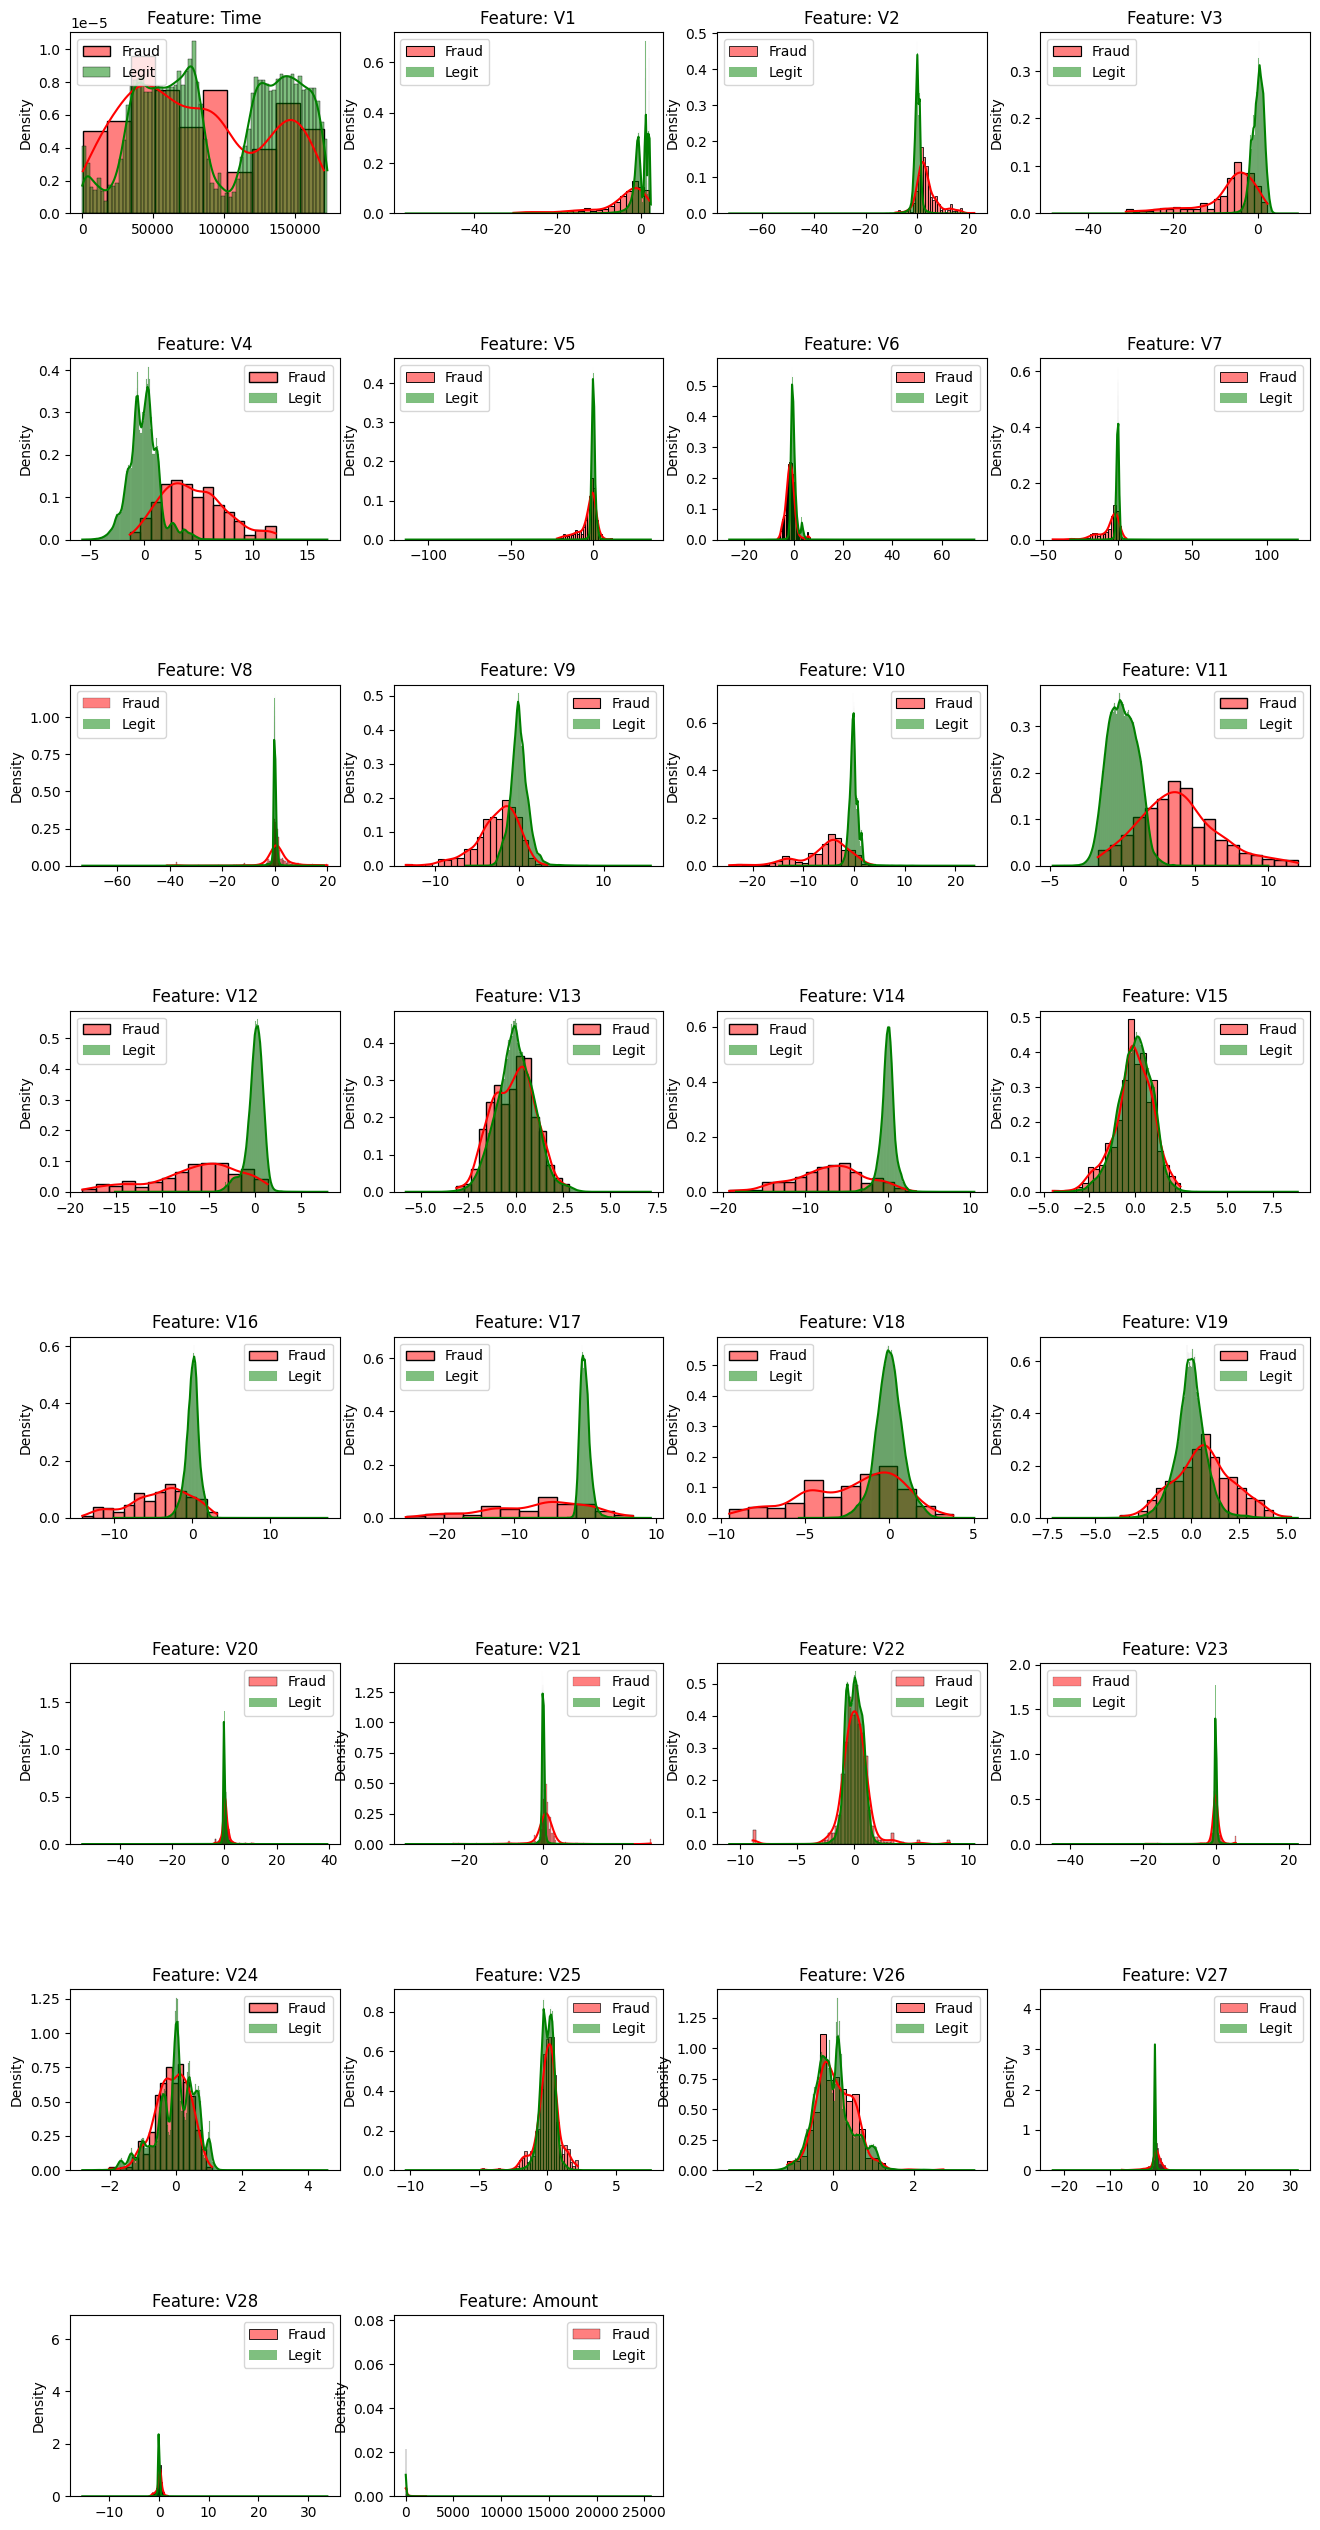

In [8]:
# Representamos gráficamente las variables
features = df.drop("Class", axis=1)

plt.figure(figsize=(16, 32))
gs = gridspec.GridSpec(8, 4)
gs.update(hspace=0.8)

for i, f in enumerate(features):
    ax = plt.subplot(gs[i])
    # Usando histplot para los casos donde Class == 1
    sns.histplot(data=df[df["Class"] == 1], x=f, kde=True, color="red", stat="density", label="Fraud", alpha=0.5)
    # Usando histplot para los casos donde Class == 0
    sns.histplot(data=df[df["Class"] == 0], x=f, kde=True, color="green", stat="density", label="Legit", alpha=0.5)
    ax.set_xlabel('')
    ax.set_title(f"Feature: {f}")
    ax.legend()

plt.show()

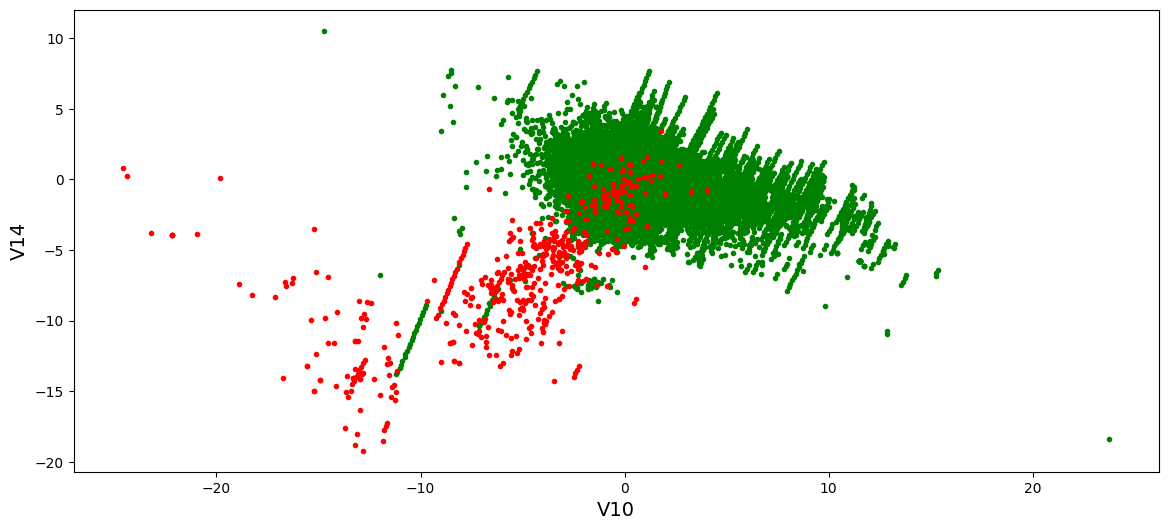

In [9]:
# Representación gráfica de dos variables
plt.figure(figsize=(14, 6))
plt.scatter(df["V10"][df['Class'] == 0], df["V14"][df['Class'] == 0], c="g", marker=".")
plt.scatter(df["V10"][df['Class'] == 1], df["V14"][df['Class'] == 1], c="r", marker=".")
plt.xlabel("V10", fontsize=14)
plt.ylabel("V14", fontsize=14)
plt.show()

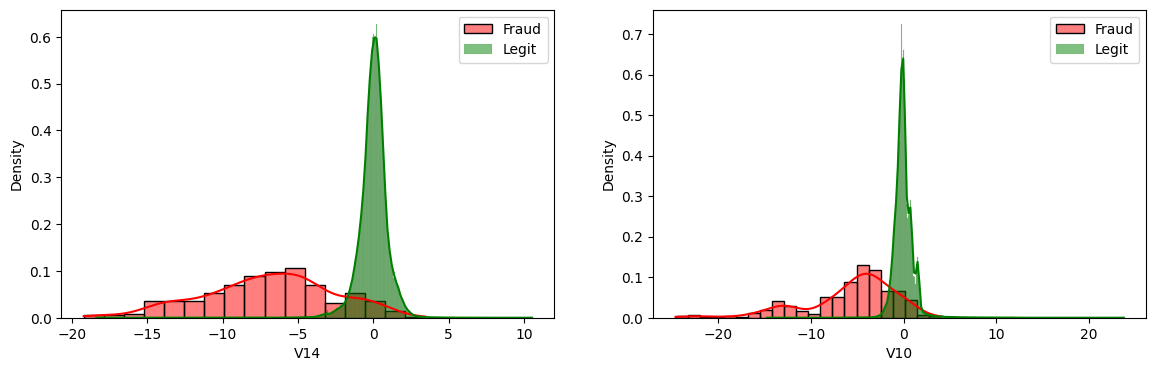

In [10]:
plt.figure(figsize=(14,4))
gs = gridspec.GridSpec(1, 2)

# Representación de la variable 1
ax = plt.subplot(gs[0])
sns.histplot(data=df[df['Class'] == 1], x="V14", kde=True, color="red", stat="density", label="Fraud", alpha=0.5)
sns.histplot(data=df[df['Class'] == 0], x="V14", kde=True, color="green", stat="density", label="Legit", alpha=0.5)
ax.legend()  # Para mostrar la leyenda

# Representación de la variable 2
ax = plt.subplot(gs[1])
sns.histplot(data=df[df['Class'] == 1], x="V10", kde=True, color="red", stat="density", label="Fraud", alpha=0.5)
sns.histplot(data=df[df['Class'] == 0], x="V10", kde=True, color="green", stat="density", label="Legit", alpha=0.5)
ax.legend()  # Para mostrar la leyenda

plt.show()

## 3. Preparación del conjunto de datos

Para este tipo de algoritmos es importante que todos los datos se encuentren en un rango similar, por lo tanto, podemos aplicar una función de escalado o normalización. Otra opción, es eliminar las variables que no se encuentran en un rango similar siempre y cuando no sean muy influyentes para la predicción.

In [11]:
df_prep = df.drop(["Time", "Amount"], axis=1)

## 4. Isolation Forest con un conjunto de datos de dos dimensiones

Antes de comenzar con la detección de anomalías mediante Isoltaion Forest para todos los atributos del conjunto de datos, se realiza una prueba para dos variables con el objetivo de comprender como construye el límite de decisión.

In [12]:
X = df_prep.drop("Class", axis=1)
y = df_prep["Class"]

In [13]:
X_reduced = X[["V10", "V14"]]

**Entrenamiento del algoritmo con un conjunto de datos reducido**
- *la caja negra*

In [37]:
from sklearn.ensemble import IsolationForest

ift_clf = IsolationForest(contamination=0.05, max_samples=300)
ift_clf.fit(X_reduced)

IsolationForest(contamination=0.05, max_samples=300)

**Representación del límite de decisión**

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(


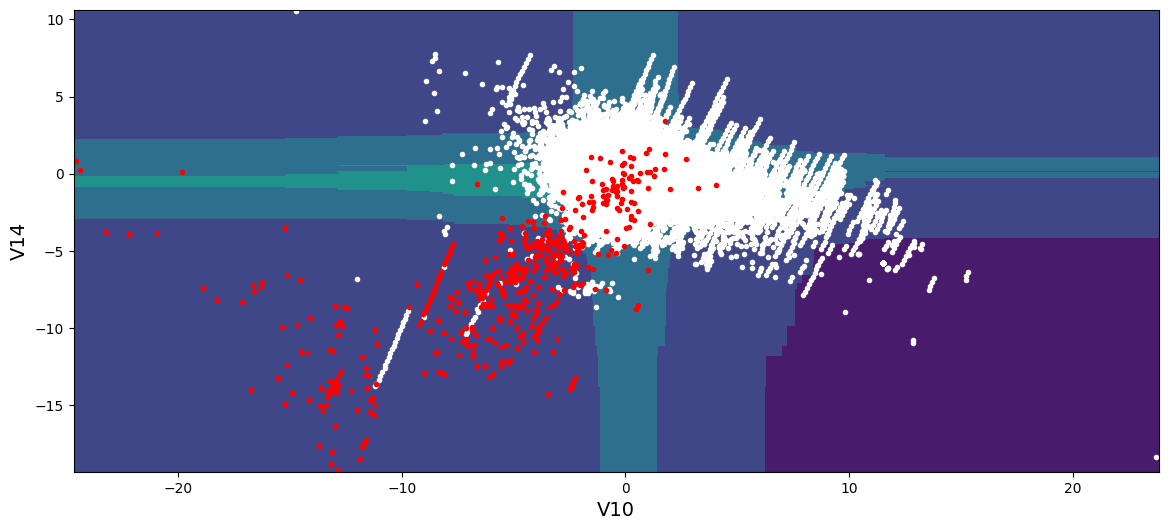

In [28]:
def plot_isolation_forest(X, y, resolution=1000):
    mins = X.min(axis=0) - 0.1
    maxs = X.max(axis=0) + 0.1
    xx, yy = np.meshgrid(np.linspace(mins[0], maxs[0], resolution),
                         np.linspace(mins[1], maxs[1], resolution))

    Z = ift_clf.decision_function(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z)

    plt.plot(X[:, 0][y==0], X[:, 1][y==0], 'w.')
    plt.plot(X[:, 0][y==1], X[:, 1][y==1], 'r.')

plt.figure(figsize=(14, 6))
plot_isolation_forest(X_reduced.values, y)
plt.xlabel("V10", fontsize=14)
plt.ylabel("V14", fontsize=14)
plt.show()

-Entre más oscuro más anómalo
- Las cruces son los cortes
- Contaminación de 0.05

**Representación de las anomalías identificadas**

In [29]:
# Identificación de anomalías
anomalies = ift_clf.predict(X_reduced)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(


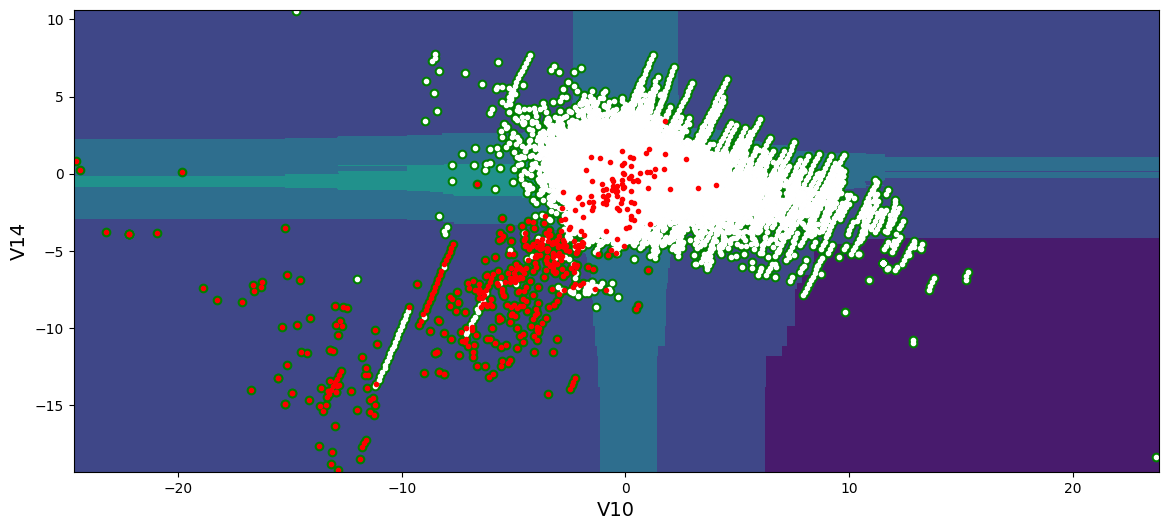

In [30]:
# Representación gráfica de las anomalías
plt.figure(figsize=(14, 6))
plt.plot(X_reduced["V10"][anomalies == -1], X_reduced["V14"][anomalies == -1], 'go', markersize=6)
plot_isolation_forest(X_reduced.values, y)
plt.xlabel("V10", fontsize=14)
plt.ylabel("V14", fontsize=14)
plt.show()

**Predicción con el conjunto de datos reducido**

In [31]:
print("Total de anomalías identificadas:", len(y[anomalies==-1]))

Total de anomalías identificadas: 14241


In [32]:
# Listado de los puntos anómalos
X_reduced[anomalies==-1]

,V10,V14
82,6.051521,-2.837136
102,0.127497,-4.318378
104,0.791069,-2.678081
108,-1.444036,-3.279054
132,3.014355,-1.599749
...,...,...
284758,0.295649,-2.591114
284765,3.714089,-0.173248
284772,2.769699,0.758186
284795,8.655320,1.288401


## 5. Isolation Forest con un conjunto de datos multidimensional

In [38]:
# Entrenamiento del modelo
ift_clf = IsolationForest(max_samples=1000, contamination=0.01)
ift_clf.fit(X)

IsolationForest(contamination=0.01, max_samples=1000)

In [39]:
# Identificación de anomalías
anomalies = ift_clf.predict(X)

In [40]:
print("Total de anomalías identificadas:", len(y[anomalies==-1]))

Total de anomalías identificadas: 2849


In [41]:
# Listado de los puntos anómalos
X[anomalies==-1]

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28
164,-6.093248,-12.114213,-5.694973,3.294389,-1.413792,4.776000,4.808426,-0.228197,-0.525896,-1.724899,...,-0.978442,7.744222,2.228823,-2.264037,-3.553381,1.215279,-0.406073,-0.653384,-0.711222,0.672900
362,-2.564961,2.470985,2.649417,-1.564256,1.794297,-0.614742,4.185906,-3.855359,5.436633,8.737458,...,-0.428482,3.564138,-1.672706,-0.463149,-0.532466,0.306494,0.226844,-0.365416,-0.936735,-2.733887
601,-3.133891,2.887394,2.178690,-1.576535,1.434510,-0.687313,3.816056,-3.416915,5.459274,8.821756,...,-0.464409,3.585628,-1.659610,-0.498518,-0.476668,0.302196,0.299993,-0.359155,-0.958818,-2.735623
1158,-6.169664,6.118940,-1.667775,-1.206991,-0.021373,-1.208458,2.184989,-1.512188,6.450992,11.906868,...,-0.355886,4.843083,-1.127086,0.261435,0.136166,0.413380,0.666632,-0.530568,2.464962,0.365892
1388,-3.936794,-3.670519,-1.453820,2.299750,-9.749440,6.456410,10.784088,-2.160016,-0.238116,-1.004398,...,-0.810785,-2.203676,-0.979104,0.957186,2.441960,0.250607,0.300908,1.157867,1.624284,-1.638647
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284393,-4.571996,4.001637,-0.686328,-2.340542,1.680291,-0.634889,3.478058,-2.874886,6.437965,10.448215,...,-0.188422,3.715161,-1.182248,1.511540,-0.372606,-0.430795,-0.079541,-0.715266,-1.310732,-3.320889
284448,-5.128786,4.434560,-1.152573,-2.357638,1.316643,-0.703130,3.111958,-2.436404,6.459490,10.532284,...,-0.223530,3.734697,-1.169530,1.479393,-0.302331,-0.435989,-0.003085,-0.708154,-1.330861,-3.323162
284649,-11.946976,9.772660,-8.006237,-2.498596,-4.229520,-1.320039,-3.259766,5.059956,4.870093,8.570504,...,-0.535565,3.468419,-0.957977,-1.529035,0.838689,-1.249172,1.714495,0.314623,2.112848,1.234408
284795,-12.516732,10.187818,-8.476671,-2.510473,-4.586669,-1.394465,-3.632516,5.498583,4.893089,8.655320,...,-0.571605,3.490065,-0.944759,-1.565026,0.890675,-1.253276,1.786717,0.320763,2.090712,1.232864
